# Data Cleaning and Exploratory Analysis

### Imports

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm

### Downloading and Cleaning Data

In [16]:
# mom = UMD monthly returns
# ff = Fama-French Three-Factor Model (Market Excess Return, Small Minus Big, High Minus Low, Risk-Free-Rate)

In [17]:
mom = pd.read_csv('F-F_Momentum_Factor.csv', skiprows=13, index_col=0)
mom.index = mom.index.astype(str).str.strip()
mom = mom[mom.index.str.match(r'^\d{6}$')]
mom.index = pd.to_datetime(mom.index, format='%Y%m')
mom = mom.apply(pd.to_numeric, errors='coerce')
mom = mom / 100

ff_daily = pd.read_csv('F-F_Research_Data_Factors_daily.csv', skiprows=4, index_col=0)
ff_daily.index = ff_daily.index.astype(str).str.strip()
ff_daily = ff_daily[ff_daily.index.str.match(r'^\d{8}$')]
ff_daily.index = pd.to_datetime(ff_daily.index, format='%Y%m%d')
ff_daily = ff_daily.apply(pd.to_numeric, errors='coerce')
ff_daily = ff_daily / 100
ff_daily = ff_daily['2000':'2024']
realized_vol = ff_daily['Mkt-RF'].resample('ME').std() * (21 ** 0.5)
realized_vol.name = 'RealVol'
realized_vol.index = realized_vol.index.to_period('M').to_timestamp()
realized_vol_df = realized_vol.to_frame()
realized_vol_df['RealVol_lag'] = realized_vol_df['RealVol'].shift(1)

ff = pd.read_csv('F-F_Research_Data_Factors.csv', skiprows=4, index_col=0)
ff.index = ff.index.astype(str).str.strip()
ff = ff[ff.index.str.match(r'^\d{6}$')]
ff.index = pd.to_datetime(ff.index, format='%Y%m')
ff = ff.apply(pd.to_numeric, errors='coerce')
ff = ff / 100

print(mom.head())
print(ff_daily.head())
print(ff.head())
print(mom.shape)
print(ff_daily.shape)
print(ff.shape)

               Mom
1927-01-01  0.0057
1927-02-01 -0.0150
1927-03-01  0.0352
1927-04-01  0.0436
1927-05-01  0.0278
            Mkt-RF     SMB     HML      RF
2000-01-03 -0.0071  0.0055 -0.0131  0.0002
2000-01-04 -0.0406 -0.0002  0.0207  0.0002
2000-01-05 -0.0009  0.0031 -0.0005  0.0002
2000-01-06 -0.0074 -0.0043  0.0124  0.0002
2000-01-07  0.0321 -0.0040 -0.0157  0.0002
            Mkt-RF     SMB     HML      RF
1926-07-01  0.0289 -0.0255 -0.0239  0.0022
1926-08-01  0.0264 -0.0114  0.0381  0.0025
1926-09-01  0.0038 -0.0136  0.0005  0.0023
1926-10-01 -0.0327 -0.0014  0.0082  0.0032
1926-11-01  0.0254 -0.0011 -0.0061  0.0031
(1188, 1)
(6289, 4)
(1194, 4)


In [18]:
vix_monthly = pd.read_csv('VIXCLS-2.csv', index_col=0)
vix_monthly.index = pd.to_datetime(vix_monthly.index)
vix_monthly['VIX_lag'] = vix_monthly['VIXCLS'].shift(1)
vix_monthly = vix_monthly['2000':'2024']
print(vix_monthly.head())

                  VIXCLS  VIX_lag
observation_date                 
2000-01-01         24.95    24.64
2000-02-01         23.37    24.95
2000-03-01         24.11    23.37
2000-04-01         26.20    24.11
2000-05-01         23.65    26.20


### Merging and Filtering Data

In [19]:
df = mom.join(ff, how='inner')
df = df['2000':'2024']
df = df.join(vix_monthly[['VIXCLS', 'VIX_lag']], how='left')
df = df.rename(columns={'VIXCLS': 'VIX'})
df = df.join(realized_vol_df[['RealVol', 'RealVol_lag']], how='left')


df['Mkt12m'] = (1 + df['Mkt-RF'] + df['RF']).rolling(12).apply(np.prod) - 1
df['Mkt12m_lag'] = df['Mkt12m'].shift(1)

df['MomRecent'] = (1 + df['Mom']).rolling(6).apply(np.prod) - 1
df['MomRecent_lag'] = df['MomRecent'].shift(1)

df['Excess_Returns'] = df['Mom'] - df['RF']
mean_excess = df['Excess_Returns'].mean()
std_excess = df['Excess_Returns'].std()
sharpe = (mean_excess / std_excess) * np.sqrt(12)

downside_dev = np.sqrt(np.mean(np.minimum(df['Excess_Returns'], 0)**2))
sortino = (mean_excess / downside_dev) * np.sqrt(12)

cumulative = (1 + df['Mom']).cumprod()
rolling_max = cumulative.cummax()
drawdown = (cumulative - rolling_max) / rolling_max
max_drawdown = drawdown.min()

print(df.shape)
print(df.head())
print(df.tail())
print(df.isnull().sum())

print(f"Sharpe: {sharpe:.3f}")
print(f"Sortino: {sortino:.3f}")
print(f"Max Drawdown: {max_drawdown:.3f}")

(300, 14)
               Mom  Mkt-RF     SMB     HML      RF    VIX  VIX_lag   RealVol  \
2000-01-01  0.0186 -0.0474  0.0516 -0.0112  0.0041  24.95    24.64  0.077962   
2000-02-01  0.1802  0.0246  0.2125 -0.0977  0.0043  23.37    24.95  0.054776   
2000-03-01 -0.0685  0.0521 -0.1741  0.0850  0.0047  24.11    23.37  0.077523   
2000-04-01 -0.0860 -0.0639 -0.0600  0.0645  0.0046  26.20    24.11  0.113517   
2000-05-01 -0.0899 -0.0439 -0.0608  0.0459  0.0050  23.65    26.20  0.081499   

            RealVol_lag  Mkt12m  Mkt12m_lag  MomRecent  MomRecent_lag  \
2000-01-01          NaN     NaN         NaN        NaN            NaN   
2000-02-01     0.077962     NaN         NaN        NaN            NaN   
2000-03-01     0.054776     NaN         NaN        NaN            NaN   
2000-04-01     0.077523     NaN         NaN        NaN            NaN   
2000-05-01     0.113517     NaN         NaN        NaN            NaN   

            Excess_Returns  
2000-01-01          0.0145  
2000-02-01  

In [20]:
windows = {'Full': ('2000', '2024'), 'Train': ('2000', '2009'), 'Test': ('2010', '2024')}

for label, (start, end) in windows.items():
    subset = df.loc[start:end]
    excess = subset['Mom'] - subset['RF']
    sharpe = (excess.mean() / excess.std()) * np.sqrt(12)
    downside_dev = np.sqrt(np.mean(np.minimum(excess, 0)**2))
    sortino = (excess.mean() / downside_dev) * np.sqrt(12)
    cumulative = (1 + subset['Mom']).cumprod()
    drawdown = (cumulative - cumulative.cummax()) / cumulative.cummax()
    max_dd = drawdown.min()
    print(f"\n{label} ({start}–{end})")
    print(f"  Sharpe:       {sharpe:.3f}")
    print(f"  Sortino:      {sortino:.3f}")
    print(f"  Max Drawdown: {max_dd:.3f}")


Full (2000–2024)
  Sharpe:       0.022
  Sortino:      0.028
  Max Drawdown: -0.578

Train (2000–2009)
  Sharpe:       -0.074
  Sortino:      -0.093
  Max Drawdown: -0.578

Test (2010–2024)
  Sharpe:       0.147
  Sortino:      0.199
  Max Drawdown: -0.254


### Cumulative Returns Plot (2000-2024)

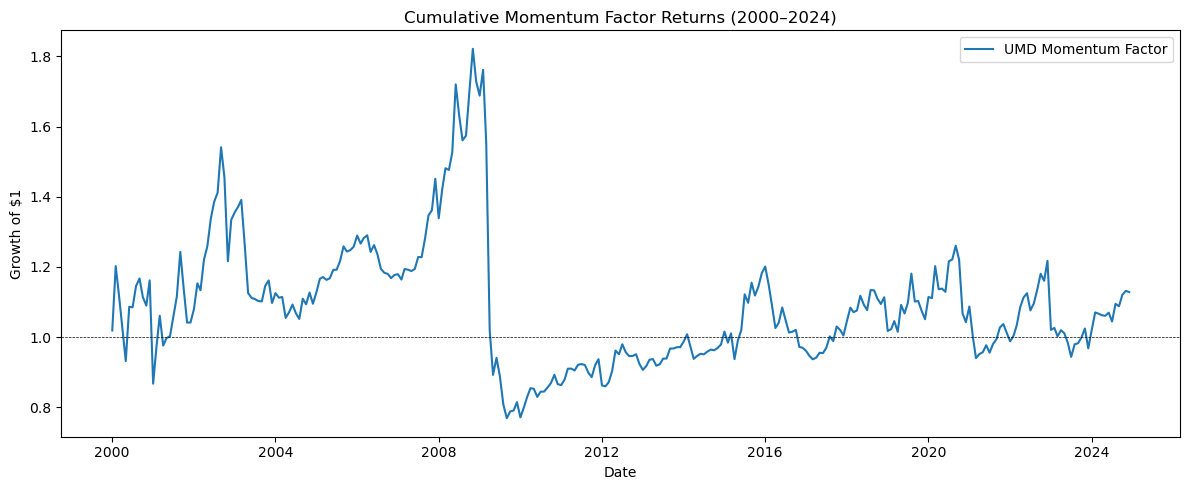

In [21]:
cumulative_mom = (1 + df['Mom']).cumprod()

plt.figure(figsize=(12, 5))
plt.plot(cumulative_mom.index, cumulative_mom, label='UMD Momentum Factor')
plt.title('Cumulative Momentum Factor Returns (2000–2024)')
plt.xlabel('Date')
plt.ylabel('Growth of $1')
plt.axhline(y=1, color='black', linestyle='--', linewidth=0.5)
plt.legend()
plt.tight_layout()
plt.show()

### Drawdowns Plot (2000-2024)

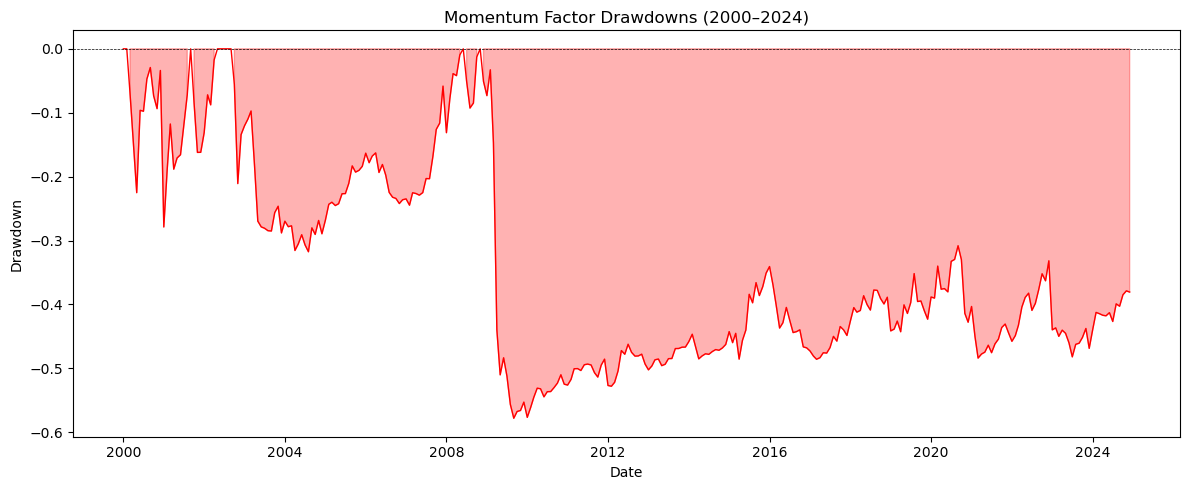

In [22]:
drawdown = (cumulative_mom - cumulative_mom.cummax()) / cumulative_mom.cummax()

plt.figure(figsize=(12, 5))
plt.fill_between(drawdown.index, drawdown, 0, where=(drawdown < 0), color='red', alpha=0.3)
plt.plot(drawdown.index, drawdown, color='red', linewidth=1)
plt.title('Momentum Factor Drawdowns (2000–2024)')
plt.xlabel('Date')
plt.ylabel('Drawdown')
plt.axhline(y=0, color='black', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

### Signal Features with Spikes

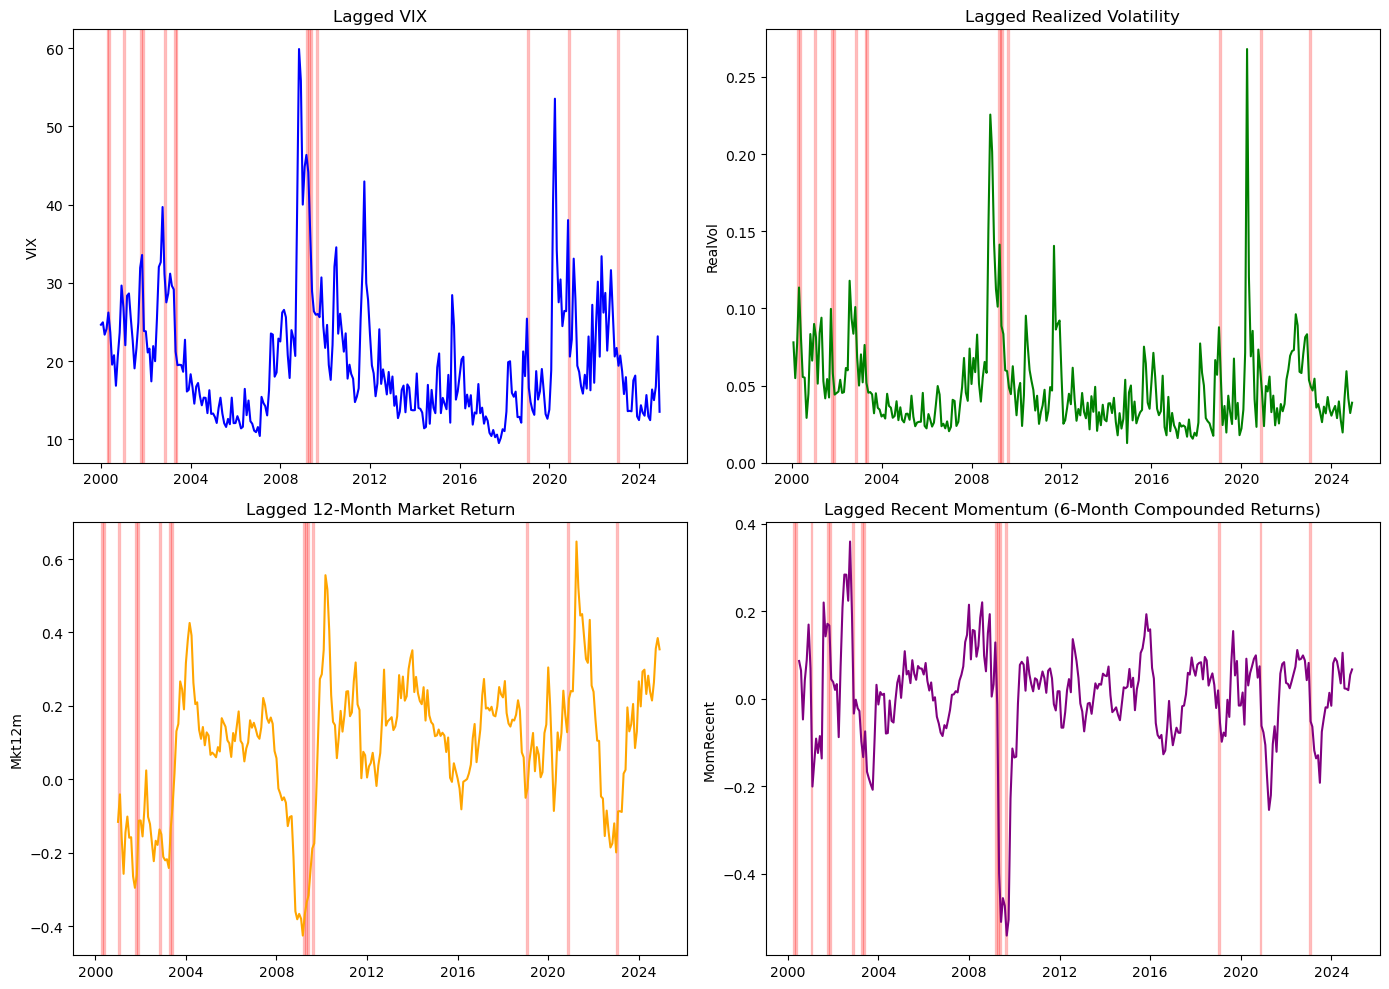

In [23]:
crash_threshold = df['2000':'2009']['Mom'].quantile(0.10)
crash_months = df[df['Mom'] <= crash_threshold].index

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# VIX
axes[0, 0].plot(df.index, df['VIX_lag'], color='blue')
axes[0, 0].set_title('Lagged VIX')
axes[0, 0].set_ylabel('VIX')

# RealVol
axes[0, 1].plot(df.index, df['RealVol_lag'], color='green')
axes[0, 1].set_title('Lagged Realized Volatility')
axes[0, 1].set_ylabel('RealVol')

# Mkt12m
axes[1, 0].plot(df.index, df['Mkt12m_lag'], color='orange')
axes[1, 0].set_title('Lagged 12-Month Market Return')
axes[1, 0].set_ylabel('Mkt12m')

# MomRecent
axes[1, 1].plot(df.index, df['MomRecent_lag'], color='purple')
axes[1, 1].set_title('Lagged Recent Momentum (6-Month Compounded Returns)')
axes[1, 1].set_ylabel('MomRecent')

for ax in axes.flat:
    for date in crash_months:
        ax.axvspan(date, date + pd.DateOffset(months=1), color='red', alpha=0.2)

plt.tight_layout()
plt.show()

### Signal Correlation Heatmap

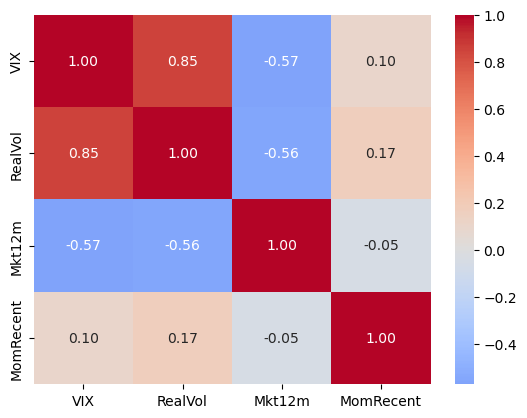

In [24]:
corr = df[['VIX', 'RealVol', 'Mkt12m', 'MomRecent']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.show()

### UMD Returns Distribution

Skewness: -1.478
Kurtosis: 9.274


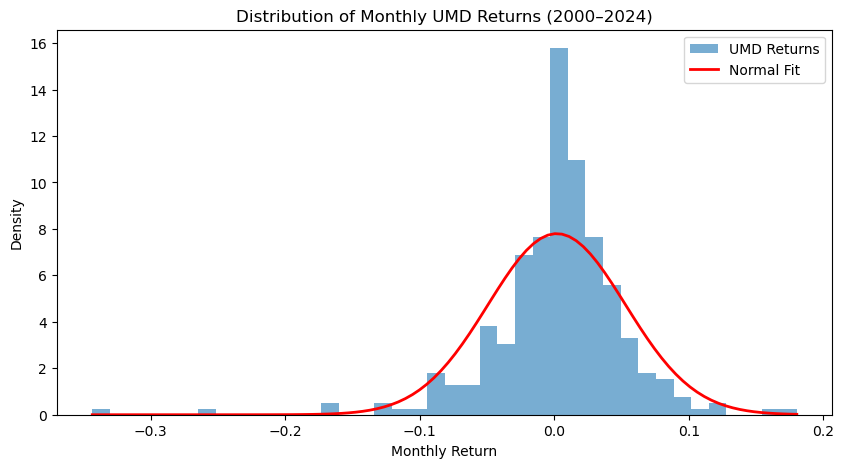

In [25]:
x = np.linspace(df['Mom'].min(), df['Mom'].max(), 100)
mu, std = stats.norm.fit(df['Mom'])

plt.figure(figsize=(10, 5))
plt.hist(df['Mom'], bins=40, density=True, alpha=0.6, label='UMD Returns')
plt.plot(x, stats.norm.pdf(x, mu, std), 'r-', linewidth=2, label='Normal Fit')
plt.title('Distribution of Monthly UMD Returns (2000–2024)')
plt.xlabel('Monthly Return')
plt.ylabel('Density')
plt.legend()

print(f"Skewness: {df['Mom'].skew():.3f}")
print(f"Kurtosis: {df['Mom'].kurt():.3f}")

### Signal Significance Testing

In [26]:
train = df['2000':'2009']

train_crash_months = train[train['Mom'] <= crash_threshold].index

is_crash_train = train.index.isin(train_crash_months)

signals = ['VIX_lag', 'RealVol_lag', 'Mkt12m_lag', 'MomRecent_lag']

for signal in signals:
    crash_vals = train.loc[is_crash_train, signal].dropna()
    non_crash_vals = train.loc[~is_crash_train, signal].dropna()
    mean_crash = crash_vals.mean()
    mean_non_crash = non_crash_vals.mean()
    t_stat, p_val = stats.ttest_ind(crash_vals, non_crash_vals, equal_var=False)
    print(f"Signal: {signal}")
    print(f"  Mean (crash): {mean_crash:.4f} | Mean (non-crash): {mean_non_crash:.4f}")
    print(f"  t-stat: {t_stat} | p-value: {p_val}")

Signal: VIX_lag
  Mean (crash): 31.4217 | Mean (non-crash): 20.8694
  t-stat: 4.429044306785573 | p-value: 0.0005451029589837854
Signal: RealVol_lag
  Mean (crash): 0.0881 | Mean (non-crash): 0.0522
  t-stat: 4.453940076284474 | p-value: 0.00043682819187097635
Signal: Mkt12m_lag
  Mean (crash): -0.2504 | Mean (non-crash): 0.0204
  t-stat: -7.061019614781317 | p-value: 4.082900999918002e-06
Signal: MomRecent_lag
  Mean (crash): -0.0388 | Mean (non-crash): 0.0073
  t-stat: -0.5997376903443524 | p-value: 0.5624303841611278


In [27]:
# MomRecent_lag excluded: univariate t-test (Cell 21) found it insignificant (p=0.56)
train = df['2000':'2009'].dropna(subset=['VIX_lag', 'RealVol_lag', 'Mkt12m_lag'])
crash_threshold = train['Mom'].quantile(0.10)
y = (train['Mom'] <= crash_threshold).astype(int)

X = train[['VIX_lag', 'RealVol_lag', 'Mkt12m_lag']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

logit = sm.Logit(y, sm.add_constant(X_scaled)).fit()
print(logit.summary())

Optimization terminated successfully.
         Current function value: 0.214299
         Iterations 9
                           Logit Regression Results                           
Dep. Variable:                    Mom   No. Observations:                  108
Model:                          Logit   Df Residuals:                      104
Method:                           MLE   Df Model:                            3
Date:                Tue, 31 Mar 2026   Pseudo R-squ.:                  0.3489
Time:                        11:08:22   Log-Likelihood:                -23.144
converged:                       True   LL-Null:                       -35.546
Covariance Type:            nonrobust   LLR p-value:                 1.697e-05
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -3.8898      0.886     -4.389      0.000      -5.627      -2.153
x1            -0.7279      1.

In [28]:
df.to_pickle('momentum_df.pkl')

### EDA Findings & Summary

#### Key Findings:

- Negative skew and high kurtosis indicates fat left tail. This supports Daniel and Moskowitz findings regarding strong momentum crashes.

-  Momentum never fully recovers post-2009.

- Lagged VIX, Real Volatility, and Market 12-Month Returns were all statistically significant predictors of crash months.

- t-test shows that lagged Recent Momentum is not a statistically significant predictors of crash months (p-value = 0.5624).

- Joint Logistic regression showed that real volatility has no independent predictive power conditional on lagged VIX (p-value = 0.952).

#### Methodological Decisions:

- Crashes are labeled as the bottom 10th percentile of the training window (2000-2009) monthly UMD returns.

- All signal features are lagged by one month to ensure ex-ante implementability.

- Compounded returns used for Mkt12m and MomRecent rather than summed